# The Model
$$
\dot{x_i}(t) = x_i(t) \left(1-x_i(t) + \sum_j A_{ij} \alpha_{ij} x_j(t)\right)
$$
Where:
- $A_{ij}$ is the adjacency matrix
- $\alpha_{ij}$ is the interaction strength

## Interaction Strength
The interaction strength can be decomposed in the following way:
$$
\alpha_{ij} = \frac{\mu}{C} + \frac{\sigma}{\sqrt{C}} z_{ij}
$$
where the pair $(z_{ij}, z_{ji})$ are jointly Gaussian distributed with:
- $\overline{z_{ij}} = 0$
- $\overline{z_{ij}^2} = 1$
- $\overline{z_{ij}z_{ji}} = \gamma$

In the end the controlling parameters are:
- $\mu$ which controles the average strength, for $\mu > 0$ we get a cooperative regime while for $\mu < 0$ we get a competitive regime
- $\sigma$ which controles the disomogeneity of the interactions between different pairs of nodes
- $\gamma$ controls the asymmetry of the interaction within the same pair of nodes

In the end there are two sources of disorder, the adjacency matrix $A_{ij}$ and the interaction disomogenity $\alpha_{ij}$, the latter can be killed in the homogenous case ($\sigma = 0$)

## Adjacency Matrix
The graph has for each node a degree $k$, but we will use the high limit continuous version given by $g = \frac{k}{C}$ hence
$$
\nu(g) =\lim_{C\rightarrow \infty} \sum_{k=0}^\infty p(k) \delta\left(g - \frac{k}{C}\right)
$$

In [76]:
import numpy as np

N = 3000
C = 50
mu = 0.25
sigma = 0

degrees = np.random.exponential(C, size=N)
degrees = np.round(degrees).astype(int)

if degrees.sum() % 2 != 0:
    degrees[np.random.randint(0, N)] += 1

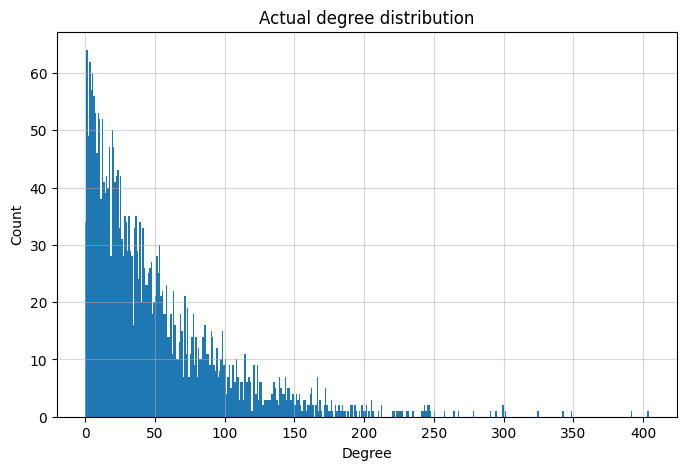

In [77]:
import matplotlib.pyplot as plt
from glv.dynamics import simulate_glv
from glv.graph import generate_matrix

A = generate_matrix(degrees, C, mu=mu, sigma=sigma)

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=np.arange(degrees.min(), degrees.max() + 1))
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Actual degree distribution")
plt.grid(alpha=0.5)
plt.show()

In [71]:
# Print the mean and variance of the generated degree distribution
print(f"Mean degree: {degrees.mean():.2f}")
print(f"Variance of degree: {degrees.var():.2f}")   

Mean degree: 48.86
Variance of degree: 2419.67


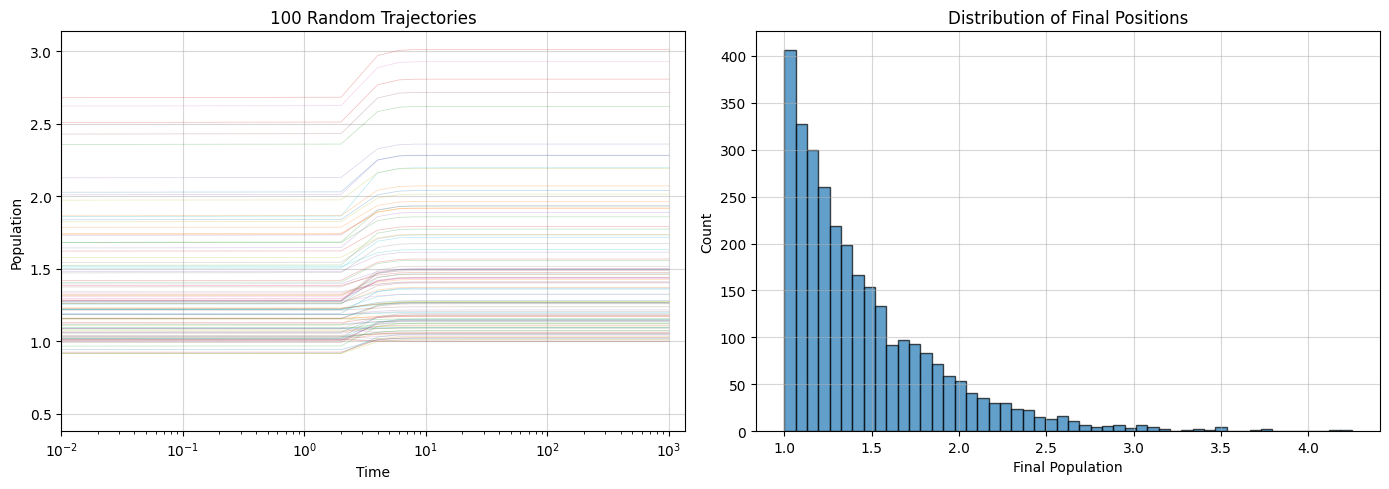

In [78]:
# Initialize random initial conditions
x0 = np.random.rand(N) + 0.5

# Simulate GLV dynamics 
x, t = simulate_glv(A, x0, tmax=1000)

# Plot 100 random trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Select 100 random nodes
random_nodes = np.random.choice(N, size=100, replace=False)

# Plot trajectories
for node in random_nodes:
    axes[0].plot(t, x[:, node], alpha=0.3, linewidth=0.5)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Population")
axes[0].set_title("100 Random Trajectories")
axes[0].set_xscale('log')
axes[0].set_xlim(left=0.01)
axes[0].grid(alpha=0.5)

# Plot distribution of final positions
final_positions = x[-1, :]
axes[1].hist(final_positions, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Final Population")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Final Positions")
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.show()